In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [3]:
np.random.seed(42)
X = np.sort(5 * np.random.rand(100,1) , axis = 0)
y = np.sin(X).ravel() + np.random.randn(100)*0.1

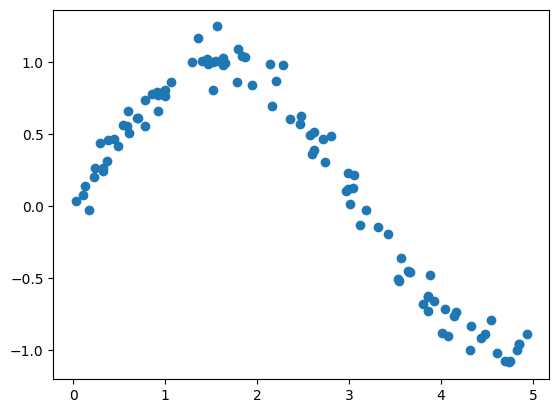

In [15]:
plt.scatter(X,y)
plt.xlabel = 'X'
plt.show()

In [5]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.2 , random_state = 40)

In [17]:
poly_transformer = PolynomialFeatures(degree = 3 , include_bias = False)


In [18]:
X_train_poly = poly_transformer.fit_transform(X_train)
X_test_poly = poly_transformer.transform(X_test)

In [19]:
model = LinearRegression()

In [30]:
model.fit(X_train_poly , y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 1.95,-0.89, 0.09]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.2366
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](3,)","[326.93, 12.4 , 1.2 ]"


In [31]:
y_pred = model.predict(X_test_poly)

In [32]:
print("Training Score (R2):", model.score(X_train_poly, y_train))
print("Testing Score (R2):", model.score(X_test_poly, y_test))

Training Score (R2): 0.9734415567030198
Testing Score (R2): 0.9857563537454316


In [34]:
lr = LinearRegression()
lr.fit(X_train, y_train)
print("Linear R2:", lr.score(X_test, y_test))
print("Polynomial R2:", model.score(X_test_poly, y_test))

Linear R2: 0.6338932129486583
Polynomial R2: 0.9857563537454316


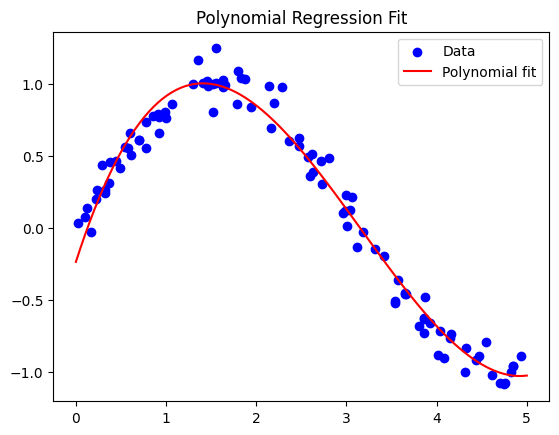

In [23]:
X_plot = np.linspace(0, 5, 100).reshape(-1, 1)
X_plot_poly = poly_transformer.transform(X_plot)
y_plot = model.predict(X_plot_poly)

plt.scatter(X, y, color='blue', label='Data')
plt.plot(X_plot, y_plot, color='red', label='Polynomial fit')
plt.xlabel='X'
plt.ylabel='y'
plt.title('Polynomial Regression Fit')
plt.legend()
plt.show()

In [37]:
for degree in range(1,10):
     poly = PolynomialFeatures(degree=degree, include_bias=False)
     X_train_p = poly.fit_transform(X_train)
     X_test_p = poly.transform(X_test)
     model = LinearRegression()
     model.fit(X_train_p, y_train)
     print(f"Degree {degree} — Train R2: {model.score(X_train_p, y_train):.4f}, Test R2: {model.score(X_test_p, y_test):.4f}") 

Degree 1 — Train R2: 0.6057, Test R2: 0.6339
Degree 2 — Train R2: 0.8700, Test R2: 0.8928
Degree 3 — Train R2: 0.9734, Test R2: 0.9858
Degree 4 — Train R2: 0.9799, Test R2: 0.9885
Degree 5 — Train R2: 0.9823, Test R2: 0.9860
Degree 6 — Train R2: 0.9823, Test R2: 0.9861
Degree 7 — Train R2: 0.9826, Test R2: 0.9851
Degree 8 — Train R2: 0.9773, Test R2: 0.9730
Degree 9 — Train R2: 0.9577, Test R2: 0.9633
